# Análise Exploratória do Dataset de Imagens Visuais

Este notebook apresenta uma análise exploratória geral das imagens presentes no diretório `data/visual`. O objetivo é entender melhor as características das imagens que compõem o nosso dataset consolidado, incluindo:

1. **Visão Geral**: Quantidade total de imagens e tamanho em disco.
2. **Distribuição por Fonte**: Identificação e contagem das imagens originárias de cada sub-dataset (ex: `dt1`, `dt2`, etc.).
3. **Resoluções e Proporções (Aspect Ratio)**: Distribuição de larguras, alturas e proporções das imagens.
4. **Análise de Cor e Brilho**: Distribuição de intensidade dos canais RGB e brilho médio.
5. **Amostra Visual**: Exibição de um grid com amostras aleatórias das imagens.

In [1]:
# Adiciona o diretório raiz ao path para importação do módulo src, se necessário
import sys
import os
sys.path.append(os.path.abspath('../..'))

In [2]:
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fallback caso a biblioteca tqdm não esteja instalada
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, *args, **kwargs):
        return iterable

# Configurações de exibição de gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Diretório das imagens
IMAGE_DIR = '../../data/visual'
print(f"Diretório de imagens: {os.path.abspath(IMAGE_DIR)}")

Diretório de imagens: /home/liaan/Documentos/dumping-of-garbage/data/visual


In [3]:
# Buscar todas as imagens no diretório
image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
image_paths = []
for ext in image_extensions:
    image_paths.extend(glob.glob(os.path.join(IMAGE_DIR, ext)))

print(f"Total de imagens encontradas: {len(image_paths)}")

Total de imagens encontradas: 3345


In [4]:
# Coleta de metadados das imagens
data = []

# Analisar as imagens
for path in tqdm(image_paths, desc="Analisando imagens"):
    filename = os.path.basename(path)
    file_size_kb = os.path.getsize(path) / 1024
    
    # Extrair fonte do dataset pelo nome (ex: lixo-dt1-00003.jpg -> dt1)
    parts = filename.split('-')
    source = parts[1] if len(parts) >= 3 else 'unknown'
    
    try:
        # Carregar imagem para extrair dimensões e estatísticas de cor
        img = cv2.imread(path)
        if img is None:
            print(f"Aviso: Não foi possível ler a imagem {filename}")
            continue
            
        height, width, channels = img.shape
        aspect_ratio = width / height
        
        # Estatísticas de cor (BGR -> RGB)
        mean_b, mean_g, mean_r = np.mean(img, axis=(0, 1))
        std_b, std_g, std_r = np.std(img, axis=(0, 1))
        
        # Brilho médio (Luminância média usando fórmula ITU-R BT.601)
        brightness = 0.299 * mean_r + 0.587 * mean_g + 0.114 * mean_b
        
        data.append({
            'filename': filename,
            'path': path,
            'source': source,
            'file_size_kb': file_size_kb,
            'width': width,
            'height': height,
            'aspect_ratio': aspect_ratio,
            'mean_r': mean_r,
            'mean_g': mean_g,
            'mean_b': mean_b,
            'std_r': std_r,
            'std_g': std_g,
            'std_b': std_b,
            'brightness': brightness
        })
    except Exception as e:
        print(f"Erro ao processar a imagem {filename}: {str(e)}")

# Criar DataFrame pandas
df = pd.DataFrame(data)
print(f"\nProcessamento concluído. {len(df)} imagens carregadas com sucesso.")


Processamento concluído. 3345 imagens carregadas com sucesso.


In [5]:
# Visualizar as primeiras linhas e resumo estatístico geral
df.head()

,filename,path,source,file_size_kb,width,height,aspect_ratio,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness
0,lixo-dt5-00003.jpg,../../data/visual/lixo-dt5-00003.jpg,dt5,79.039062,640,640,1.0,176.153938,179.023315,170.949138,51.260921,46.936757,66.263153,177.244915
1,lixo-dt2-01736.jpg,../../data/visual/lixo-dt2-01736.jpg,dt2,354.057617,640,640,1.0,133.860305,120.281089,104.282690,65.584107,64.765721,61.521860,122.517457
2,lixo-dt6-00064.jpg,../../data/visual/lixo-dt6-00064.jpg,dt6,50.943359,416,416,1.0,75.154401,60.112056,51.739934,47.831281,50.455433,56.513567,63.655295
3,lixo-dt5-00315.jpg,../../data/visual/lixo-dt5-00315.jpg,dt5,79.264648,640,640,1.0,92.985486,95.386086,86.213401,62.517170,59.563955,64.185983,93.622621
4,lixo-dt2-01560.jpg,../../data/visual/lixo-dt2-01560.jpg,dt2,209.972656,640,640,1.0,127.440430,114.907048,99.746560,60.418555,58.890962,57.810250,116.926234


In [6]:
df.describe()

,file_size_kb,width,height,aspect_ratio,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness
count,3345.000000,3345.000000,3345.000000,3345.0,3345.000000,3345.000000,3345.000000,3345.000000,3345.000000,3345.000000,3345.000000
mean,183.287617,621.316592,621.316592,1.0,124.293858,121.800461,112.591779,56.312625,52.947840,55.393293,121.496197
std,90.832271,61.944821,61.944821,0.0,25.251199,24.365325,27.413301,10.270076,10.361551,10.436437,24.134543
min,17.865234,416.000000,416.000000,1.0,8.310486,12.887627,11.511304,11.753739,19.774948,22.694301,12.709813
25%,93.934570,640.000000,640.000000,1.0,112.207244,110.222861,97.006282,49.575099,45.817999,47.836554,109.639506
50%,183.206055,640.000000,640.000000,1.0,126.888347,124.303977,113.003372,56.368521,53.040634,55.725446,123.798004
75%,257.031250,640.000000,640.000000,1.0,140.079441,137.055740,131.023904,63.375910,60.456961,62.439927,137.081090
max,378.506836,640.000000,640.000000,1.0,198.034985,200.842378,202.335195,102.874451,100.407401,99.688042,199.561415


## 1. Distribuição por Fonte de Dados (Dataset de Origem)

Análise de qual dataset de origem veio cada imagem, baseando-se no padrão de nome de arquivo `lixo-[origem]-[ID].jpg`.

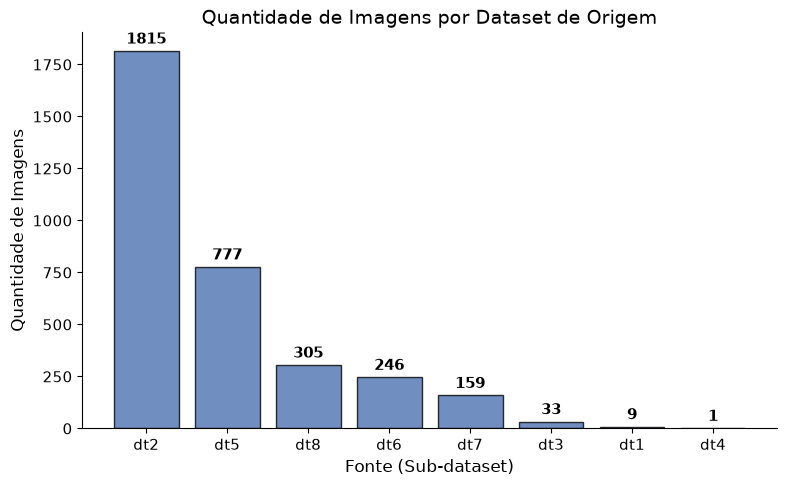

Resumo de Distribuição:
        Quantidade  Porcentagem (%)
source                             
dt2           1815            54.26
dt5            777            23.23
dt8            305             9.12
dt6            246             7.35
dt7            159             4.75
dt3             33             0.99
dt1              9             0.27
dt4              1             0.03


In [7]:
if not df.empty:
    source_counts = df['source'].value_counts()
    
    # Plotar distribuição das fontes
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(source_counts.index, source_counts.values, color='#4C72B0', edgecolor='black', alpha=0.8)
    
    # Adicionar os valores no topo das barras
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + (max(source_counts.values)*0.01), 
                f'{int(yval)}', ha='center', va='bottom', fontweight='bold')
                
    ax.set_title('Quantidade de Imagens por Dataset de Origem')
    ax.set_xlabel('Fonte (Sub-dataset)')
    ax.set_ylabel('Quantidade de Imagens')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    
    # Tabela com as porcentagens
    print("Resumo de Distribuição:")
    dist_df = pd.DataFrame({
        'Quantidade': source_counts,
        'Porcentagem (%)': (source_counts / len(df) * 100).round(2)
    })
    print(dist_df)
else:
    print("Nenhum dado disponível.")

## 2. Análise de Resolução e Dimensões

Investigamos as larguras e alturas das imagens, as resoluções mais frequentes e as proporções (aspect ratio).

Resoluções mais frequentes no dataset:
         Quantidade  Porcentagem (%)
640x640        3066            91.66
416x416         279             8.34


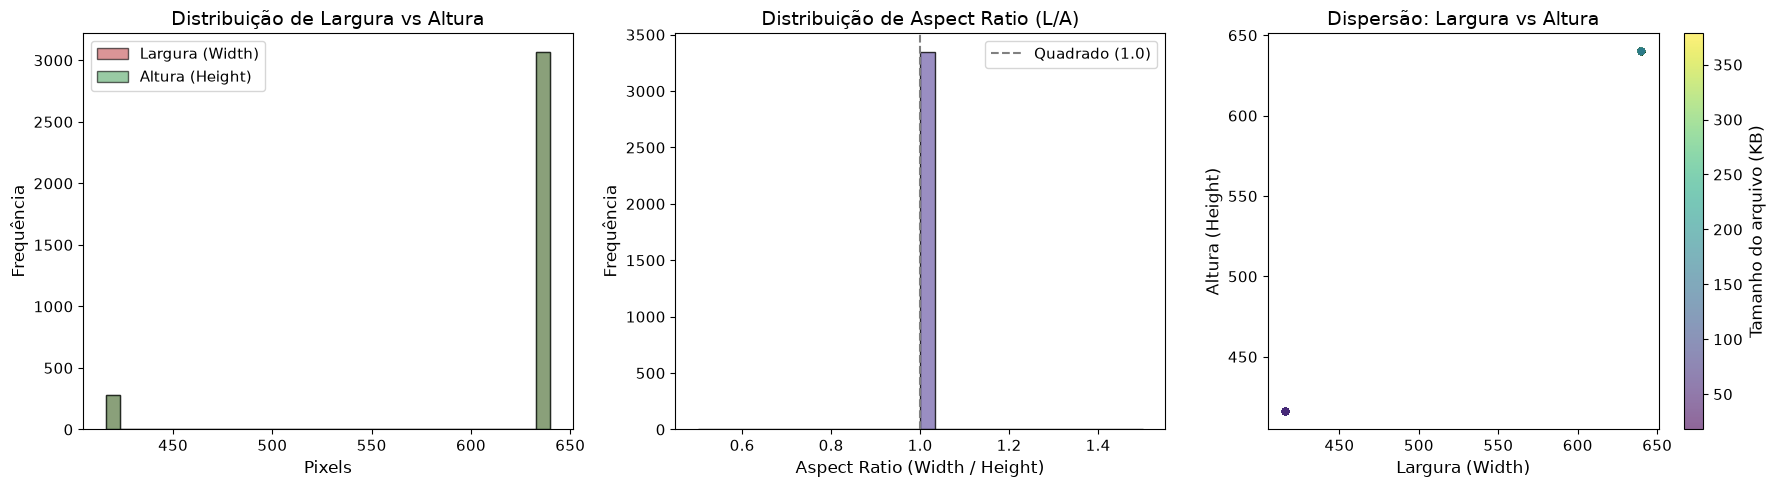

In [8]:
if not df.empty:
    # Agrupar por combinações únicas de (width, height)
    resolutions = df.apply(lambda row: f"{row['width']}x{row['height']}", axis=1)
    res_counts = resolutions.value_counts()
    
    print("Resoluções mais frequentes no dataset:")
    print(pd.DataFrame({
        'Quantidade': res_counts,
        'Porcentagem (%)': (res_counts / len(df) * 100).round(2)
    }))
    
    # Criar subplots para analisar dimensões
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Histograma de Larguras e Alturas
    axes[0].hist(df['width'], bins=30, alpha=0.6, label='Largura (Width)', color='#C44E52', edgecolor='black')
    axes[0].hist(df['height'], bins=30, alpha=0.6, label='Altura (Height)', color='#55A868', edgecolor='black')
    axes[0].set_title('Distribuição de Largura vs Altura')
    axes[0].set_xlabel('Pixels')
    axes[0].set_ylabel('Frequência')
    axes[0].legend()
    
    # 2. Histograma de Aspect Ratio
    axes[1].hist(df['aspect_ratio'], bins=30, color='#8172B3', edgecolor='black', alpha=0.8)
    axes[1].axvline(x=1.0, color='gray', linestyle='--', label='Quadrado (1.0)')
    axes[1].set_title('Distribuição de Aspect Ratio (L/A)')
    axes[1].set_xlabel('Aspect Ratio (Width / Height)')
    axes[1].set_ylabel('Frequência')
    axes[1].legend()
    
    # 3. Dispersão de Largura vs Altura
    scatter = axes[2].scatter(df['width'], df['height'], c=df['file_size_kb'], cmap='viridis', alpha=0.6, edgecolors='none', s=30)
    axes[2].set_title('Dispersão: Largura vs Altura')
    axes[2].set_xlabel('Largura (Width)')
    axes[2].set_ylabel('Altura (Height)')
    cbar = fig.colorbar(scatter, ax=axes[2])
    cbar.set_label('Tamanho do arquivo (KB)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado disponível.")

## 3. Análise de Tamanho de Arquivo (KB)

Como varia o tamanho do arquivo em disco? Imagens maiores em pixels tendem a ocupar mais espaço, mas a complexidade visual e a compressão JPEG também influenciam.

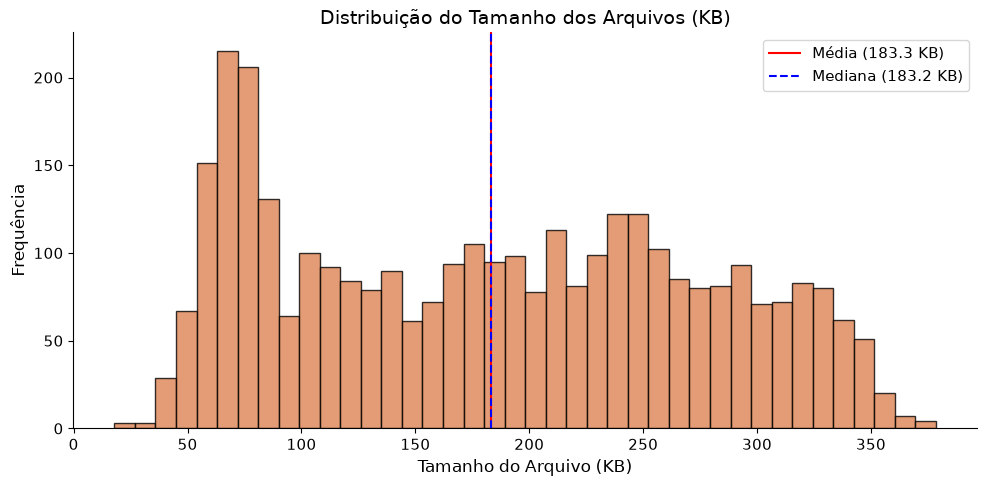

In [9]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df['file_size_kb'], bins=40, color='#DD8452', edgecolor='black', alpha=0.8)
    
    # Estatísticas de apoio
    mean_size = df['file_size_kb'].mean()
    median_size = df['file_size_kb'].median()
    
    ax.axvline(mean_size, color='red', linestyle='-', linewidth=1.5, label=f'Média ({mean_size:.1f} KB)')
    ax.axvline(median_size, color='blue', linestyle='--', linewidth=1.5, label=f'Mediana ({median_size:.1f} KB)')
    
    ax.set_title('Distribuição do Tamanho dos Arquivos (KB)')
    ax.set_xlabel('Tamanho do Arquivo (KB)')
    ax.set_ylabel('Frequência')
    ax.legend()
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado disponível.")

## 4. Análise de Canal de Cor e Brilho

Esta análise avalia os canais RGB médios das imagens e o nível de brilho (luminância). Isso é útil para entender as condições de iluminação e tonalidades predominantes no dataset (ex: predominância de tons verdes, cinzas, iluminação noturna vs diurna).

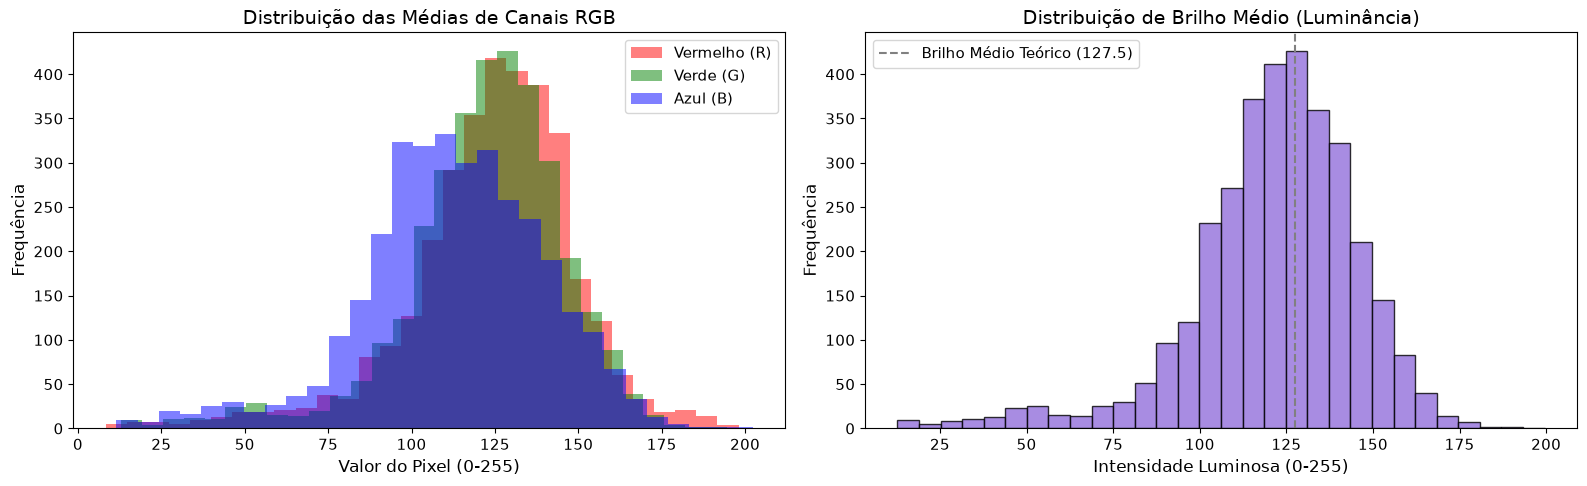

Médias gerais de cor no dataset:
  - Canal Vermelho (R): 124.29 (± 56.31)
  - Canal Verde (G):    121.80 (± 52.95)
  - Canal Azul (B):     112.59 (± 55.39)
  - Brilho Médio:        121.50


In [10]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. Distribuição dos canais de cores
    axes[0].hist(df['mean_r'], bins=30, alpha=0.5, label='Vermelho (R)', color='red', edgecolor='none')
    axes[0].hist(df['mean_g'], bins=30, alpha=0.5, label='Verde (G)', color='green', edgecolor='none')
    axes[0].hist(df['mean_b'], bins=30, alpha=0.5, label='Azul (B)', color='blue', edgecolor='none')
    axes[0].set_title('Distribuição das Médias de Canais RGB')
    axes[0].set_xlabel('Valor do Pixel (0-255)')
    axes[0].set_ylabel('Frequência')
    axes[0].legend()
    
    # 2. Distribuição do brilho geral
    axes[1].hist(df['brightness'], bins=30, color='#9370DB', edgecolor='black', alpha=0.8)
    axes[1].axvline(127.5, color='gray', linestyle='--', label='Brilho Médio Teórico (127.5)')
    axes[1].set_title('Distribuição de Brilho Médio (Luminância)')
    axes[1].set_xlabel('Intensidade Luminosa (0-255)')
    axes[1].set_ylabel('Frequência')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Médias gerais dos canais
    print(f"Médias gerais de cor no dataset:")
    print(f"  - Canal Vermelho (R): {df['mean_r'].mean():.2f} (± {df['std_r'].mean():.2f})")
    print(f"  - Canal Verde (G):    {df['mean_g'].mean():.2f} (± {df['std_g'].mean():.2f})")
    print(f"  - Canal Azul (B):     {df['mean_b'].mean():.2f} (± {df['std_b'].mean():.2f})")
    print(f"  - Brilho Médio:        {df['brightness'].mean():.2f}")
else:
    print("Nenhum dado disponível.")

## 5. Visualização de Amostras de Imagens

Vamos selecionar aleatoriamente algumas imagens para visualização, mostrando a resolução e o tamanho de cada uma.

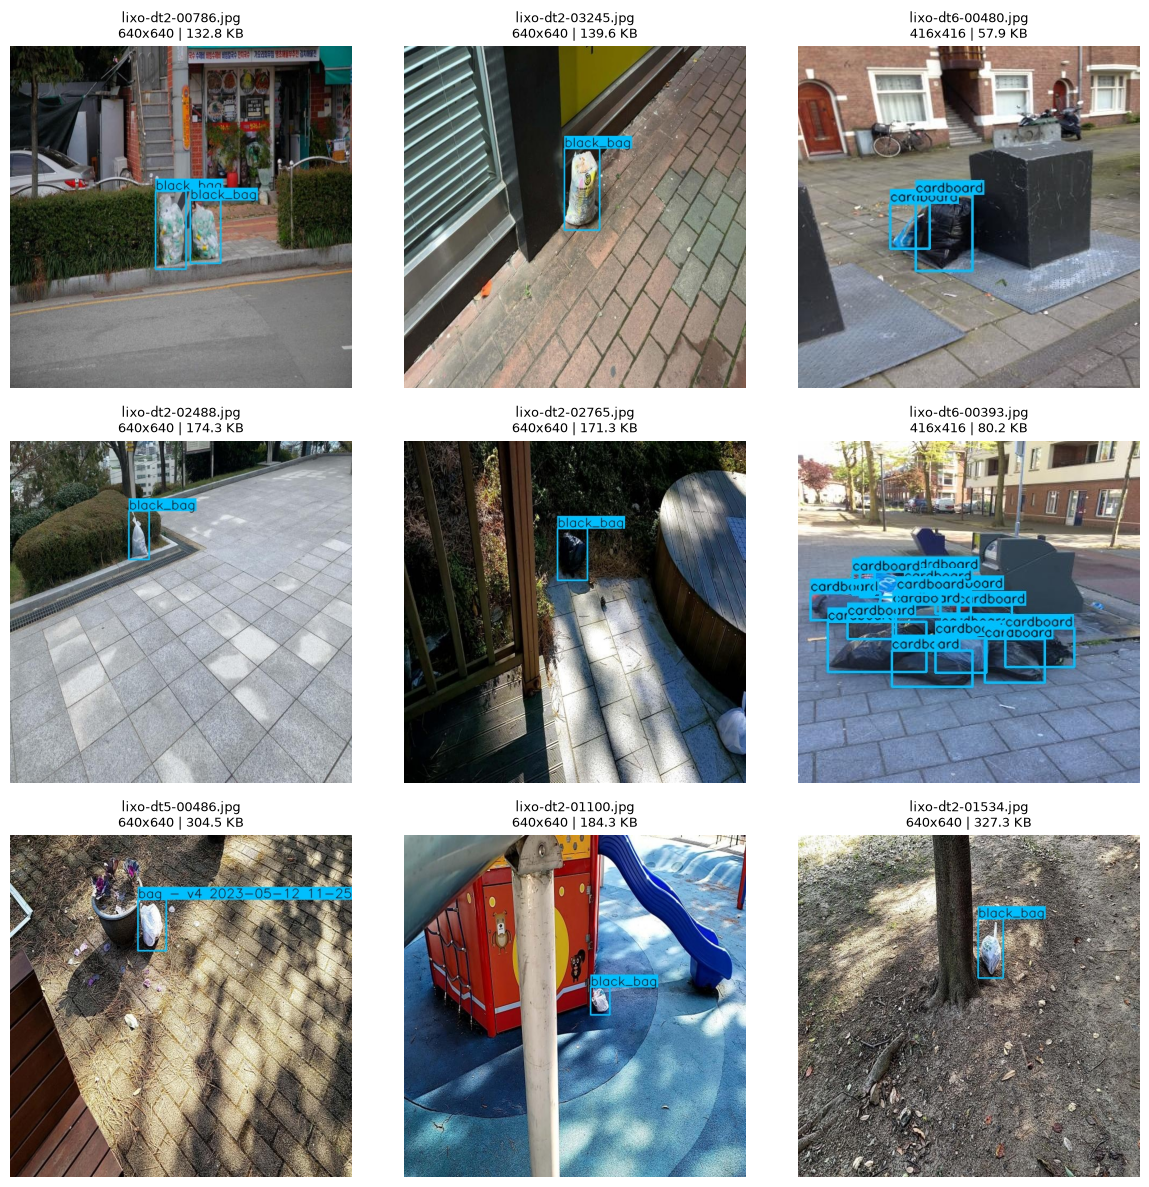

In [11]:
if not df.empty:
    # Selecionar 9 imagens aleatórias
    num_samples = min(9, len(df))
    sample_df = df.sample(n=num_samples, random_state=42)
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()
    
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        img_bgr = cv2.imread(row['path'])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"{row['filename']}\n{row['width']}x{row['height']} | {row['file_size_kb']:.1f} KB", fontsize=9)
        axes[idx].axis('off')
        
    # Desativar eixos restantes se houver menos de 9 imagens
    for idx in range(num_samples, 9):
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado disponível.")